# Credit Card Default Prediction

## data_preprocessing

This section implements the full data loading, quality audit, preprocessing, and split strategy pipeline for the UCI Credit Card Default dataset.

### Objectives
- Build a reproducible data pipeline.
- Prevent data leakage by fitting transforms on training data only.
- Document every preprocessing decision with evidence.

In [16]:
import random
import subprocess
import sys

import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Reproducibility
RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 120)

print(f"Data source: ucimlrepo (id=350) - online only")

Data source: ucimlrepo (id=350) - online only


## 1) Data Loading

In [17]:
# Fetch directly from UCI repository (online only)
try:
    from ucimlrepo import fetch_ucirepo
except ImportError:
    print("Installing ucimlrepo...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "ucimlrepo", "-q"])
    from ucimlrepo import fetch_ucirepo

default_of_credit_card_clients = fetch_ucirepo(id=350)
X_uci = default_of_credit_card_clients.data.features.copy()
y_uci = default_of_credit_card_clients.data.targets.copy()

# Normalize target to a 1D series
if isinstance(y_uci, pd.DataFrame):
    if y_uci.shape[1] == 1:
        y_uci = y_uci.iloc[:, 0]
    else:
        y_uci = y_uci.squeeze()
y_uci = y_uci.rename("default payment next month")

df_raw = pd.concat([X_uci, y_uci], axis=1)
data_source = "ucimlrepo"

print("Loaded dataset from ucimlrepo.")

# Standardize column names across both schemas (X1..X23/Y vs readable names)
column_map = {
    "X1": "LIMIT_BAL",
    "X2": "SEX",
    "X3": "EDUCATION",
    "X4": "MARRIAGE",
    "X5": "AGE",
    "X6": "PAY_0",
    "X7": "PAY_2",
    "X8": "PAY_3",
    "X9": "PAY_4",
    "X10": "PAY_5",
    "X11": "PAY_6",
    "X12": "BILL_AMT1",
    "X13": "BILL_AMT2",
    "X14": "BILL_AMT3",
    "X15": "BILL_AMT4",
    "X16": "BILL_AMT5",
    "X17": "BILL_AMT6",
    "X18": "PAY_AMT1",
    "X19": "PAY_AMT2",
    "X20": "PAY_AMT3",
    "X21": "PAY_AMT4",
    "X22": "PAY_AMT5",
    "X23": "PAY_AMT6",
    "Y": "default payment next month",
    "default.payment.next.month": "default payment next month",
}

df_raw = df_raw.rename(columns=column_map)

print(f"Data source used: {data_source}")
print(f"Shape: {df_raw.shape}")
print("Columns:")
print(df_raw.columns.tolist())

df_raw.head()

Loaded dataset from ucimlrepo.
Data source used: ucimlrepo
Shape: (30000, 24)
Columns:
['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'default payment next month']


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,20000,2,2,1,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0,1
1,120000,2,2,2,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,50000,2,2,1,37,0,0,0,0,0,0,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,50000,1,2,1,57,-1,0,-1,0,0,0,8617,5670,35835,20940,19146,19131,2000,36681,10000,9000,689,679,0


## 2) Data Quality Audit

In [4]:
target_candidates = [
    "default payment next month",
    "default.payment.next.month",
    "default_payment_next_month",
    "Y",
]

target_col = next((c for c in target_candidates if c in df_raw.columns), None)
if target_col is None:
    raise ValueError(f"Could not identify target column. Available columns: {df_raw.columns.tolist()}")

id_col = "ID" if "ID" in df_raw.columns else None

audit_df = pd.DataFrame(
    {
        "dtype": df_raw.dtypes.astype(str),
        "missing_count": df_raw.isna().sum(),
        "missing_pct": (df_raw.isna().mean() * 100).round(2),
        "n_unique": df_raw.nunique(),
    }
).sort_index()

print(f"Target column: {target_col}")
print(f"ID column detected: {id_col}")
print(f"Duplicate rows: {df_raw.duplicated().sum()}")
print("Class distribution:")
print(df_raw[target_col].value_counts(normalize=True).rename("ratio").round(4))

audit_df

Target column: default payment next month
ID column detected: None
Duplicate rows: 35
Class distribution:
default payment next month
0    0.7788
1    0.2212
Name: ratio, dtype: float64


,dtype,missing_count,missing_pct,n_unique
AGE,int64,0,0.0,56
BILL_AMT1,int64,0,0.0,22723
BILL_AMT2,int64,0,0.0,22346
BILL_AMT3,int64,0,0.0,22026
BILL_AMT4,int64,0,0.0,21548
BILL_AMT5,int64,0,0.0,21010
BILL_AMT6,int64,0,0.0,20604
EDUCATION,int64,0,0.0,7
LIMIT_BAL,int64,0,0.0,81
MARRIAGE,int64,0,0.0,4


## 2.5) Deduplication and Feature Building

This step removes duplicated rows and defines a reusable feature-building function used before train/test split.

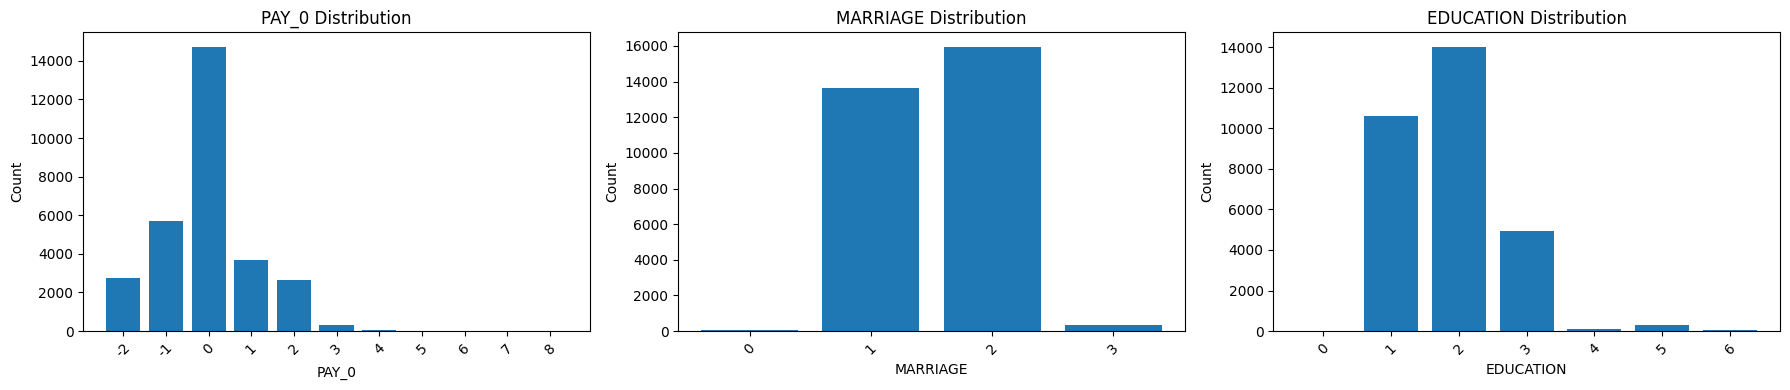

In [5]:
import matplotlib.pyplot as plt

plot_columns = ["PAY_0", "MARRIAGE", "EDUCATION"]

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for ax, col in zip(axes, plot_columns):
    if col in df_raw.columns:
        counts = df_raw[col].value_counts(dropna=False).sort_index()
        ax.bar(counts.index.astype(str), counts.values)
        ax.set_title(f"{col} Distribution")
        ax.set_xlabel(col)
        ax.set_ylabel("Count")
        ax.tick_params(axis="x", rotation=45)
    else:
        ax.set_title(f"{col} not found")
        ax.axis("off")

plt.tight_layout()
plt.show()

In [6]:
rows_before = len(df_raw)
df_nodup = df_raw.drop_duplicates().copy()
rows_after = len(df_nodup)

print(f"Rows before deduplication: {rows_before}")
print(f"Rows after deduplication: {rows_after}")
print(f"Duplicates removed: {rows_before - rows_after}")

def build_features(dataset: pd.DataFrame, target_name: str, id_name: str | None = None):
    work_df = dataset.copy()

    # Treat EDUCATION==0 and MARRIAGE==0 as missing-like invalid codes and drop those rows
    invalid_mask = pd.Series(False, index=work_df.index)
    if "EDUCATION" in work_df.columns:
        invalid_mask = invalid_mask | (work_df["EDUCATION"] == 0)
    if "MARRIAGE" in work_df.columns:
        invalid_mask = invalid_mask | (work_df["MARRIAGE"] == 0)

    invalid_rows_removed = int(invalid_mask.sum())
    work_df = work_df.loc[~invalid_mask].copy()

    drop_cols = [c for c in [id_name] if c is not None and c in work_df.columns]
    X_local = work_df.drop(columns=drop_cols + [target_name]).copy()
    y_local = work_df[target_name].astype(int)

    education_map = {
        1: "graduate_school",
        2: "university",
        3: "high_school",
        4: "others",
    }
    marriage_map = {
        1: "married",
        2: "single",
        3: "others",
    }
    repayment_code_map = {
        -2: "type_no_consumption",
        -1: "type_pay_duly",
        0: "type_revolving_credit",
        1: "type_delay_1_month",
        2: "type_delay_2_months",
        3: "type_delay_3_months",
        4: "type_delay_4_months",
        5: "type_delay_5_months",
        6: "type_delay_6_months",
        7: "type_delay_7_months",
        8: "type_delay_8_months",
        9: "type_delay_9_plus_months",
    }
    pay_cols_local = ["PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"]

    if "EDUCATION" in X_local.columns:
        X_local["EDUCATION"] = X_local["EDUCATION"].map(education_map).fillna("unknown")

    if "MARRIAGE" in X_local.columns:
        X_local["MARRIAGE"] = X_local["MARRIAGE"].map(marriage_map).fillna("unknown")

    for pay_col in pay_cols_local:
        if pay_col in X_local.columns:
            X_local[pay_col] = X_local[pay_col].map(repayment_code_map).fillna("type_unknown")

    return X_local, y_local, pay_cols_local, invalid_rows_removed

X, y, pay_cols, invalid_rows_removed = build_features(df_nodup, target_name=target_col, id_name=id_col)
print(f"Rows removed for EDUCATION/MARRIAGE invalid code 0: {invalid_rows_removed}")
print(f"Built features shape: {X.shape}")
print(f"Target shape: {y.shape}")

Rows before deduplication: 30000
Rows after deduplication: 29965
Duplicates removed: 35
Rows removed for EDUCATION/MARRIAGE invalid code 0: 68
Built features shape: (29897, 23)
Target shape: (29897,)


## 3) Split Strategy (Train/Test + K-Fold on Train)

Design choice:
- Keep a holdout test set for final evaluation.
- Use stratified train/test split to preserve class balance.
- Apply k-fold cross-validation only on the training split for model selection and tuning.
- Use a fixed random seed for reproducibility.

In [7]:
# 80/20 stratified split: holdout test + training for k-fold CV
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y,
)

def class_ratio(series: pd.Series) -> pd.Series:
    ratios = series.value_counts(normalize=True).sort_index()
    return ratios.rename(index={0: "non_default(0)", 1: "default(1)"})

split_summary = pd.DataFrame(
    {
        "rows": [len(y_train), len(y_test)],
        "default_ratio": [
            class_ratio(y_train).get("default(1)", np.nan),
            class_ratio(y_test).get("default(1)", np.nan),
        ],
    },
    index=["train", "test"],
)

print("Mapped EDUCATION values:", sorted(X["EDUCATION"].unique().tolist()) if "EDUCATION" in X.columns else "N/A")
print("Mapped MARRIAGE values:", sorted(X["MARRIAGE"].unique().tolist()) if "MARRIAGE" in X.columns else "N/A")

for pay_col in pay_cols:
    if pay_col in X.columns:
        print(f"Mapped {pay_col} values:", sorted(X[pay_col].unique().tolist()))

split_summary

Mapped EDUCATION values: ['graduate_school', 'high_school', 'others', 'university', 'unknown']
Mapped MARRIAGE values: ['married', 'others', 'single']
Mapped PAY_0 values: ['type_delay_1_month', 'type_delay_2_months', 'type_delay_3_months', 'type_delay_4_months', 'type_delay_5_months', 'type_delay_6_months', 'type_delay_7_months', 'type_delay_8_months', 'type_no_consumption', 'type_pay_duly', 'type_revolving_credit']
Mapped PAY_2 values: ['type_delay_1_month', 'type_delay_2_months', 'type_delay_3_months', 'type_delay_4_months', 'type_delay_5_months', 'type_delay_6_months', 'type_delay_7_months', 'type_delay_8_months', 'type_no_consumption', 'type_pay_duly', 'type_revolving_credit']
Mapped PAY_3 values: ['type_delay_1_month', 'type_delay_2_months', 'type_delay_3_months', 'type_delay_4_months', 'type_delay_5_months', 'type_delay_6_months', 'type_delay_7_months', 'type_delay_8_months', 'type_no_consumption', 'type_pay_duly', 'type_revolving_credit']
Mapped PAY_4 values: ['type_delay_1_mon

,rows,default_ratio
train,23917,0.221600
test,5980,0.221572


## 4) Preprocessing Pipeline (Leakage-Safe)

Design choice:
- Treat `SEX`, `EDUCATION`, `MARRIAGE`, and repayment status fields `X6-X11` (`PAY_0` to `PAY_6`) as categorical features.
- Apply semantic category mapping for `EDUCATION` (`graduate_school`, `university`, `high_school`, `others`) and `MARRIAGE` (`married`, `single`, `others`) before encoding.
- Standardize all remaining numeric features.
- Fit all preprocessing steps on training data only.

In [8]:
# After column normalization and semantic mapping, these names should always exist.
base_categorical = ["SEX", "EDUCATION", "MARRIAGE"]
pay_features = [c for c in ["PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"] if c in X_train.columns]
base_categorical = [c for c in base_categorical if c in X_train.columns]

# Explicit category scale for repayment status to keep schema stable
# even when some values (for example 1 or 9) are absent in a split.
pay_category_scale = [
    "type_no_consumption",
    "type_pay_duly",
    "type_revolving_credit",
    "type_delay_1_month",
    "type_delay_2_months",
    "type_delay_3_months",
    "type_delay_4_months",
    "type_delay_5_months",
    "type_delay_6_months",
    "type_delay_7_months",
    "type_delay_8_months",
    "type_delay_9_plus_months",
    "type_unknown",
]

transformers = []

if base_categorical:
    transformers.append(
        (
            "cat_base",
            OneHotEncoder(handle_unknown="ignore", sparse_output=False),
            base_categorical,
        )
    )

if pay_features:
    transformers.append(
        (
            "cat_pay",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False,
                categories=[pay_category_scale] * len(pay_features),
            ),
            pay_features,
        )
    )

all_categorical = base_categorical + pay_features
numeric_features = [c for c in X_train.columns if c not in all_categorical]

if numeric_features:
    transformers.append(("num", StandardScaler(), numeric_features))

preprocessor = ColumnTransformer(transformers=transformers, remainder="drop")

pipeline = Pipeline(steps=[("preprocessor", preprocessor)])

X_train_processed = pipeline.fit_transform(X_train)
X_test_processed = pipeline.transform(X_test)

print("Base categorical features:", base_categorical)
print("Repayment categorical features:", pay_features)
print("Numeric features:", len(numeric_features))
print("Processed shapes:")
print("train:", X_train_processed.shape)
print("test:", X_test_processed.shape)

# Explicit proof that PAY_* columns were one-hot encoded with the full category scale
feature_names = pipeline.named_steps["preprocessor"].get_feature_names_out()
pay_ohe_features = [name for name in feature_names if "cat_pay__PAY_" in name]

print("\nOne-hot columns created for repayment status fields:", len(pay_ohe_features))
print(pay_ohe_features[:36])

for pay_col in pay_features:
    encoded_count = sum(name.startswith(f"cat_pay__{pay_col}_") for name in pay_ohe_features)
    print(f"{pay_col}: encoded columns={encoded_count}")
    print(f"{pay_col}: raw mapped values in train={sorted(X_train[pay_col].unique().tolist())}")

Base categorical features: ['SEX', 'EDUCATION', 'MARRIAGE']
Repayment categorical features: ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
Numeric features: 14
Processed shapes:
train: (23917, 102)
test: (5980, 102)

One-hot columns created for repayment status fields: 78
['cat_pay__PAY_0_type_no_consumption', 'cat_pay__PAY_0_type_pay_duly', 'cat_pay__PAY_0_type_revolving_credit', 'cat_pay__PAY_0_type_delay_1_month', 'cat_pay__PAY_0_type_delay_2_months', 'cat_pay__PAY_0_type_delay_3_months', 'cat_pay__PAY_0_type_delay_4_months', 'cat_pay__PAY_0_type_delay_5_months', 'cat_pay__PAY_0_type_delay_6_months', 'cat_pay__PAY_0_type_delay_7_months', 'cat_pay__PAY_0_type_delay_8_months', 'cat_pay__PAY_0_type_delay_9_plus_months', 'cat_pay__PAY_0_type_unknown', 'cat_pay__PAY_2_type_no_consumption', 'cat_pay__PAY_2_type_pay_duly', 'cat_pay__PAY_2_type_revolving_credit', 'cat_pay__PAY_2_type_delay_1_month', 'cat_pay__PAY_2_type_delay_2_months', 'cat_pay__PAY_2_type_delay_3_months', 'cat_pay

In [9]:
# Compact verification: each PAY_* should get the full fixed category count
feature_names = pipeline.named_steps["preprocessor"].get_feature_names_out()

for pay_col in ["PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"]:
    prefix = f"cat_pay__{pay_col}_"
    count = int(sum(name.startswith(prefix) for name in feature_names))
    print(f"{pay_col}: one-hot columns = {count}")

PAY_0: one-hot columns = 13
PAY_2: one-hot columns = 13
PAY_3: one-hot columns = 13
PAY_4: one-hot columns = 13
PAY_5: one-hot columns = 13
PAY_6: one-hot columns = 13


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6
19082,70000,2,high_school,married,32,type_revolving_credit,type_revolving_credit,type_revolving_credit,type_revolving_credit,type_delay_2_months,type_revolving_credit,14180,10856,10822,13627,10852,12676,3000,2000,3000,0,2000,3000
10550,230000,2,university,single,28,type_revolving_credit,type_revolving_credit,type_revolving_credit,type_revolving_credit,type_revolving_credit,type_revolving_credit,23063,14024,11825,14765,12383,10008,2000,2000,5000,1000,2000,1000
26122,250000,2,university,married,41,type_revolving_credit,type_revolving_credit,type_revolving_credit,type_revolving_credit,type_revolving_credit,type_revolving_credit,214301,211762,214629,204093,150752,150863,8972,9700,8960,5630,5777,5459
20074,240000,2,graduate_school,married,41,type_revolving_credit,type_revolving_credit,type_revolving_credit,type_revolving_credit,type_revolving_credit,type_revolving_credit,129776,126395,129371,132218,136003,139798,5000,5000,5000,6000,6000,5098
20370,50000,1,graduate_school,single,23,type_revolving_credit,type_revolving_credit,type_revolving_credit,type_pay_duly,type_pay_duly,type_revolving_credit,11306,6657,3565,3820,1275,1275,1069,1240,3840,1275,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18786,120000,2,graduate_school,single,27,type_pay_duly,type_pay_duly,type_pay_duly,type_pay_duly,type_pay_duly,type_pay_duly,22225,1118,490,1433,0,1096,1118,490,1433,0,1096,0
7659,70000,2,graduate_school,married,36,type_delay_2_months,type_revolving_credit,type_revolving_credit,type_revolving_credit,type_revolving_credit,type_revolving_credit,81719,85389,86287,65287,35345,9360,5000,3000,2000,3000,5000,0
2080,70000,2,graduate_school,single,24,type_revolving_credit,type_revolving_credit,type_revolving_credit,type_revolving_credit,type_revolving_credit,type_revolving_credit,69572,71233,66844,50410,44958,46655,2828,2337,1702,1800,2600,2000
9115,30000,2,university,single,22,type_revolving_credit,type_revolving_credit,type_pay_duly,type_pay_duly,type_delay_2_months,type_delay_2_months,17358,-36,23114,24727,24192,25905,0,23150,2000,0,2119,0


## 5) Cross-Validation Design (Training Split Only)

Design choice:
- 5-fold StratifiedKFold on training data only.
- Fold-level class ratios are reported to verify class balance.

In [10]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

fold_rows = []
for fold_idx, (_, val_idx) in enumerate(skf.split(X_train, y_train), start=1):
    y_fold = y_train.iloc[val_idx]
    fold_rows.append(
        {
            "fold": fold_idx,
            "rows": len(y_fold),
            "default_ratio": y_fold.mean(),
        }
    )

cv_summary = pd.DataFrame(fold_rows)
cv_summary

,fold,rows,default_ratio
0,1,4784,0.221572
1,2,4784,0.221572
2,3,4783,0.221618
3,4,4783,0.221618
4,5,4783,0.221618


In [15]:
def get_cv_folds(X_processed, y, cv_splitter, fold_labels=None):
    """
    Generate cross-validation train/validation folds.
    
    Parameters:
    -----------
    X_processed : np.ndarray or pd.DataFrame
        Preprocessed feature matrix (e.g., X_train_processed)
    y : pd.Series or np.ndarray
        Target variable (e.g., y_train)
    cv_splitter : sklearn.model_selection splitter (e.g., StratifiedKFold)
        Splitter object with .split() method
    fold_labels : list, optional
        Custom fold labels; if None, uses 1, 2, 3, ...
        
    Yields:
    -------
    fold_num : int
        Fold number (1-indexed)
    X_train_fold, X_val_fold : np.ndarray or matching type
        Train and validation feature splits for this fold
    y_train_fold, y_val_fold : matching type
        Train and validation target splits for this fold
    """
    fold_count = 0
    for train_idx, val_idx in cv_splitter.split(X_processed, y):
        fold_count += 1
        fold_label = fold_labels[fold_count - 1] if fold_labels else fold_count
        
        # Extract fold data
        if isinstance(X_processed, pd.DataFrame):
            X_train_fold = X_processed.iloc[train_idx]
            X_val_fold = X_processed.iloc[val_idx]
        else:
            X_train_fold = X_processed[train_idx]
            X_val_fold = X_processed[val_idx]
        
        if isinstance(y, pd.Series):
            y_train_fold = y.iloc[train_idx]
            y_val_fold = y.iloc[val_idx]
        else:
            y_train_fold = y[train_idx]
            y_val_fold = y[val_idx]
        
        yield fold_label, X_train_fold, X_val_fold, y_train_fold, y_val_fold


# Example usage:
print("Example: iterate through folds\n")
for fold_num, X_tr, X_val, y_tr, y_val in get_cv_folds(X_train_processed, y_train, skf):
    print(f"Fold {fold_num}:")
    print(f"  Train shape: {X_tr.shape}, Val shape: {X_val.shape}")
    print(f"  Train default ratio: {y_tr.mean():.4f}, Val default ratio: {y_val.mean():.4f}")
    print()

Example: iterate through folds

Fold 1:
  Train shape: (19133, 102), Val shape: (4784, 102)
  Train default ratio: 0.2216, Val default ratio: 0.2216

Fold 2:
  Train shape: (19133, 102), Val shape: (4784, 102)
  Train default ratio: 0.2216, Val default ratio: 0.2216

Fold 3:
  Train shape: (19134, 102), Val shape: (4783, 102)
  Train default ratio: 0.2216, Val default ratio: 0.2216

Fold 4:
  Train shape: (19134, 102), Val shape: (4783, 102)
  Train default ratio: 0.2216, Val default ratio: 0.2216

Fold 5:
  Train shape: (19134, 102), Val shape: (4783, 102)
  Train default ratio: 0.2216, Val default ratio: 0.2216



## 6) Data & Preprocessing Note (Draft Content)

Use these points directly in your 1-2 page individual note:

1. Dataset profile:
- Source: UCI Default of Credit Card Clients dataset.
- Task: Binary classification (default next month: 0/1).
- Data grain: One row per client account.

2. Data quality decisions:
- Missing-value scan and duplicate check were performed.
- Target class distribution was measured and used to justify stratified splitting.
- `ID` column treated as non-predictive and removed.

3. Preprocessing decisions:
- Nominal categories (`SEX`, `EDUCATION`, `MARRIAGE`) were one-hot encoded.
- Repayment status fields (`PAY_0` to `PAY_6`) were semantically mapped and one-hot encoded with a fixed category scale.
- Continuous features were standardized.
- Transformations were fit on training data only to prevent leakage.

4. Split/CV design:
- Stratified train/test split (80/20).
- 5-fold StratifiedKFold applied only on training data.
- Fold-level default ratios were tracked to verify balance.

5. Risk controls and limitations:
- Leakage control: no fit on test data.
- Class imbalance acknowledged and handled via stratification.
- Outlier handling intentionally conservative (retain unless team decides otherwise).

In [14]:
# Convert processed numpy arrays to pandas DataFrames with feature names
feature_names = pipeline.named_steps["preprocessor"].get_feature_names_out()

X_train_processed_df = pd.DataFrame(
    X_train_processed,
    columns=feature_names,
    index=X_train.index,
)

X_test_processed_df = pd.DataFrame(
    X_test_processed,
    columns=feature_names,
    index=X_test.index,
)

print("X_train_processed_df shape:", X_train_processed_df.shape)
print("X_test_processed_df shape:", X_test_processed_df.shape)

print("\nTrain processed preview:")
display(X_train_processed_df.head())

print("Test processed preview:")
display(X_test_processed_df.head())

X_train_processed_df shape: (23917, 102)
X_test_processed_df shape: (5980, 102)

Train processed preview:


,cat_base__SEX_1,cat_base__SEX_2,cat_base__EDUCATION_graduate_school,cat_base__EDUCATION_high_school,cat_base__EDUCATION_others,cat_base__EDUCATION_university,cat_base__EDUCATION_unknown,cat_base__MARRIAGE_married,cat_base__MARRIAGE_others,cat_base__MARRIAGE_single,cat_pay__PAY_0_type_no_consumption,cat_pay__PAY_0_type_pay_duly,cat_pay__PAY_0_type_revolving_credit,cat_pay__PAY_0_type_delay_1_month,cat_pay__PAY_0_type_delay_2_months,cat_pay__PAY_0_type_delay_3_months,cat_pay__PAY_0_type_delay_4_months,cat_pay__PAY_0_type_delay_5_months,cat_pay__PAY_0_type_delay_6_months,cat_pay__PAY_0_type_delay_7_months,cat_pay__PAY_0_type_delay_8_months,cat_pay__PAY_0_type_delay_9_plus_months,cat_pay__PAY_0_type_unknown,cat_pay__PAY_2_type_no_consumption,cat_pay__PAY_2_type_pay_duly,cat_pay__PAY_2_type_revolving_credit,cat_pay__PAY_2_type_delay_1_month,cat_pay__PAY_2_type_delay_2_months,cat_pay__PAY_2_type_delay_3_months,cat_pay__PAY_2_type_delay_4_months,cat_pay__PAY_2_type_delay_5_months,cat_pay__PAY_2_type_delay_6_months,cat_pay__PAY_2_type_delay_7_months,cat_pay__PAY_2_type_delay_8_months,cat_pay__PAY_2_type_delay_9_plus_months,cat_pay__PAY_2_type_unknown,cat_pay__PAY_3_type_no_consumption,cat_pay__PAY_3_type_pay_duly,cat_pay__PAY_3_type_revolving_credit,cat_pay__PAY_3_type_delay_1_month,cat_pay__PAY_3_type_delay_2_months,cat_pay__PAY_3_type_delay_3_months,cat_pay__PAY_3_type_delay_4_months,cat_pay__PAY_3_type_delay_5_months,cat_pay__PAY_3_type_delay_6_months,cat_pay__PAY_3_type_delay_7_months,cat_pay__PAY_3_type_delay_8_months,cat_pay__PAY_3_type_delay_9_plus_months,cat_pay__PAY_3_type_unknown,cat_pay__PAY_4_type_no_consumption,...,cat_pay__PAY_4_type_delay_1_month,cat_pay__PAY_4_type_delay_2_months,cat_pay__PAY_4_type_delay_3_months,cat_pay__PAY_4_type_delay_4_months,cat_pay__PAY_4_type_delay_5_months,cat_pay__PAY_4_type_delay_6_months,cat_pay__PAY_4_type_delay_7_months,cat_pay__PAY_4_type_delay_8_months,cat_pay__PAY_4_type_delay_9_plus_months,cat_pay__PAY_4_type_unknown,cat_pay__PAY_5_type_no_consumption,cat_pay__PAY_5_type_pay_duly,cat_pay__PAY_5_type_revolving_credit,cat_pay__PAY_5_type_delay_1_month,cat_pay__PAY_5_type_delay_2_months,cat_pay__PAY_5_type_delay_3_months,cat_pay__PAY_5_type_delay_4_months,cat_pay__PAY_5_type_delay_5_months,cat_pay__PAY_5_type_delay_6_months,cat_pay__PAY_5_type_delay_7_months,cat_pay__PAY_5_type_delay_8_months,cat_pay__PAY_5_type_delay_9_plus_months,cat_pay__PAY_5_type_unknown,cat_pay__PAY_6_type_no_consumption,cat_pay__PAY_6_type_pay_duly,cat_pay__PAY_6_type_revolving_credit,cat_pay__PAY_6_type_delay_1_month,cat_pay__PAY_6_type_delay_2_months,cat_pay__PAY_6_type_delay_3_months,cat_pay__PAY_6_type_delay_4_months,cat_pay__PAY_6_type_delay_5_months,cat_pay__PAY_6_type_delay_6_months,cat_pay__PAY_6_type_delay_7_months,cat_pay__PAY_6_type_delay_8_months,cat_pay__PAY_6_type_delay_9_plus_months,cat_pay__PAY_6_type_unknown,num__LIMIT_BAL,num__AGE,num__BILL_AMT1,num__BILL_AMT2,num__BILL_AMT3,num__BILL_AMT4,num__BILL_AMT5,num__BILL_AMT6,num__PAY_AMT1,num__PAY_AMT2,num__PAY_AMT3,num__PAY_AMT4,num__PAY_AMT5,num__PAY_AMT6
19082,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.749930,-0.374157,-0.505170,-0.540651,-0.522627,-0.463098,-0.486660,-0.441622,-0.158710,-0.165286,-0.127540,-0.304972,-0.184867,-0.127760
10550,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.478004,-0.808114,-0.385016,-0.496313,-0.508210,-0.445450,-0.

Test processed preview:


,cat_base__SEX_1,cat_base__SEX_2,cat_base__EDUCATION_graduate_school,cat_base__EDUCATION_high_school,cat_base__EDUCATION_others,cat_base__EDUCATION_university,cat_base__EDUCATION_unknown,cat_base__MARRIAGE_married,cat_base__MARRIAGE_others,cat_base__MARRIAGE_single,cat_pay__PAY_0_type_no_consumption,cat_pay__PAY_0_type_pay_duly,cat_pay__PAY_0_type_revolving_credit,cat_pay__PAY_0_type_delay_1_month,cat_pay__PAY_0_type_delay_2_months,cat_pay__PAY_0_type_delay_3_months,cat_pay__PAY_0_type_delay_4_months,cat_pay__PAY_0_type_delay_5_months,cat_pay__PAY_0_type_delay_6_months,cat_pay__PAY_0_type_delay_7_months,cat_pay__PAY_0_type_delay_8_months,cat_pay__PAY_0_type_delay_9_plus_months,cat_pay__PAY_0_type_unknown,cat_pay__PAY_2_type_no_consumption,cat_pay__PAY_2_type_pay_duly,cat_pay__PAY_2_type_revolving_credit,cat_pay__PAY_2_type_delay_1_month,cat_pay__PAY_2_type_delay_2_months,cat_pay__PAY_2_type_delay_3_months,cat_pay__PAY_2_type_delay_4_months,cat_pay__PAY_2_type_delay_5_months,cat_pay__PAY_2_type_delay_6_months,cat_pay__PAY_2_type_delay_7_months,cat_pay__PAY_2_type_delay_8_months,cat_pay__PAY_2_type_delay_9_plus_months,cat_pay__PAY_2_type_unknown,cat_pay__PAY_3_type_no_consumption,cat_pay__PAY_3_type_pay_duly,cat_pay__PAY_3_type_revolving_credit,cat_pay__PAY_3_type_delay_1_month,cat_pay__PAY_3_type_delay_2_months,cat_pay__PAY_3_type_delay_3_months,cat_pay__PAY_3_type_delay_4_months,cat_pay__PAY_3_type_delay_5_months,cat_pay__PAY_3_type_delay_6_months,cat_pay__PAY_3_type_delay_7_months,cat_pay__PAY_3_type_delay_8_months,cat_pay__PAY_3_type_delay_9_plus_months,cat_pay__PAY_3_type_unknown,cat_pay__PAY_4_type_no_consumption,...,cat_pay__PAY_4_type_delay_1_month,cat_pay__PAY_4_type_delay_2_months,cat_pay__PAY_4_type_delay_3_months,cat_pay__PAY_4_type_delay_4_months,cat_pay__PAY_4_type_delay_5_months,cat_pay__PAY_4_type_delay_6_months,cat_pay__PAY_4_type_delay_7_months,cat_pay__PAY_4_type_delay_8_months,cat_pay__PAY_4_type_delay_9_plus_months,cat_pay__PAY_4_type_unknown,cat_pay__PAY_5_type_no_consumption,cat_pay__PAY_5_type_pay_duly,cat_pay__PAY_5_type_revolving_credit,cat_pay__PAY_5_type_delay_1_month,cat_pay__PAY_5_type_delay_2_months,cat_pay__PAY_5_type_delay_3_months,cat_pay__PAY_5_type_delay_4_months,cat_pay__PAY_5_type_delay_5_months,cat_pay__PAY_5_type_delay_6_months,cat_pay__PAY_5_type_delay_7_months,cat_pay__PAY_5_type_delay_8_months,cat_pay__PAY_5_type_delay_9_plus_months,cat_pay__PAY_5_type_unknown,cat_pay__PAY_6_type_no_consumption,cat_pay__PAY_6_type_pay_duly,cat_pay__PAY_6_type_revolving_credit,cat_pay__PAY_6_type_delay_1_month,cat_pay__PAY_6_type_delay_2_months,cat_pay__PAY_6_type_delay_3_months,cat_pay__PAY_6_type_delay_4_months,cat_pay__PAY_6_type_delay_5_months,cat_pay__PAY_6_type_delay_6_months,cat_pay__PAY_6_type_delay_7_months,cat_pay__PAY_6_type_delay_8_months,cat_pay__PAY_6_type_delay_9_plus_months,cat_pay__PAY_6_type_unknown,num__LIMIT_BAL,num__AGE,num__BILL_AMT1,num__BILL_AMT2,num__BILL_AMT3,num__BILL_AMT4,num__BILL_AMT5,num__BILL_AMT6,num__PAY_AMT1,num__PAY_AMT2,num__PAY_AMT3,num__PAY_AMT4,num__PAY_AMT5,num__PAY_AMT6
3161,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.903422,-0.808114,-0.651295,-0.633022,-0.617714,-0.663667,-0.660362,-0.653079,-0.275116,-0.072698,-0.251328,-0.290138,-0.313946,-0.295129
10907,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.135963,-0.591136,-0.462264,-0.393949,-0.386330,-0.339683,-0.